
PREDICTED PROBABILITIES — First 20 Patients
 Patient  Diagnosis (1=Anxiety, 0=No)  Logistic Regression (%)  Random Forest (%)  XGBoost (%)
       1                            1                    81.56              72.52        69.38
       2                            0                     0.25               0.56         0.17
       3                            0                     0.44               6.66         0.17
       4                            0                     6.21               8.65        11.31
       5                            0                     0.00               0.00         0.00
       6                            0                    55.64              59.92        60.57
       7                            0                    21.18              37.76        24.89
       8                            0                    15.98              18.06        15.15
       9                            0                     1.55               5.29         1.14
     

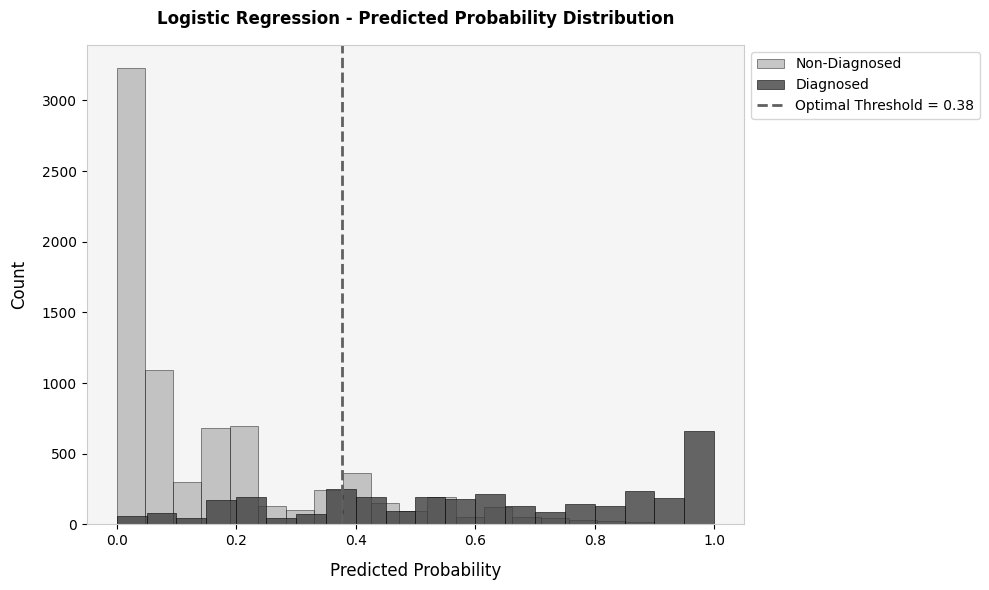

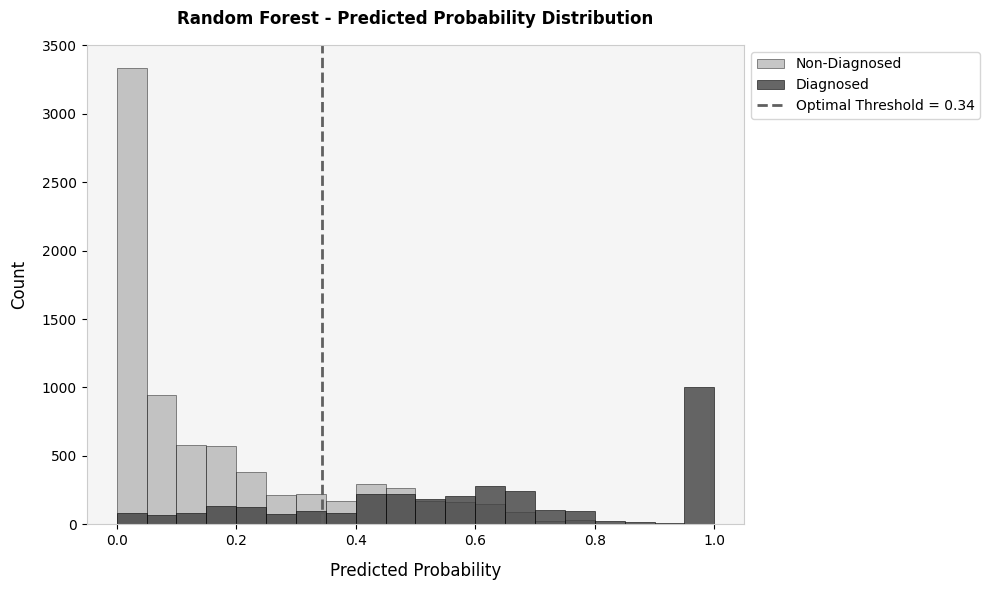

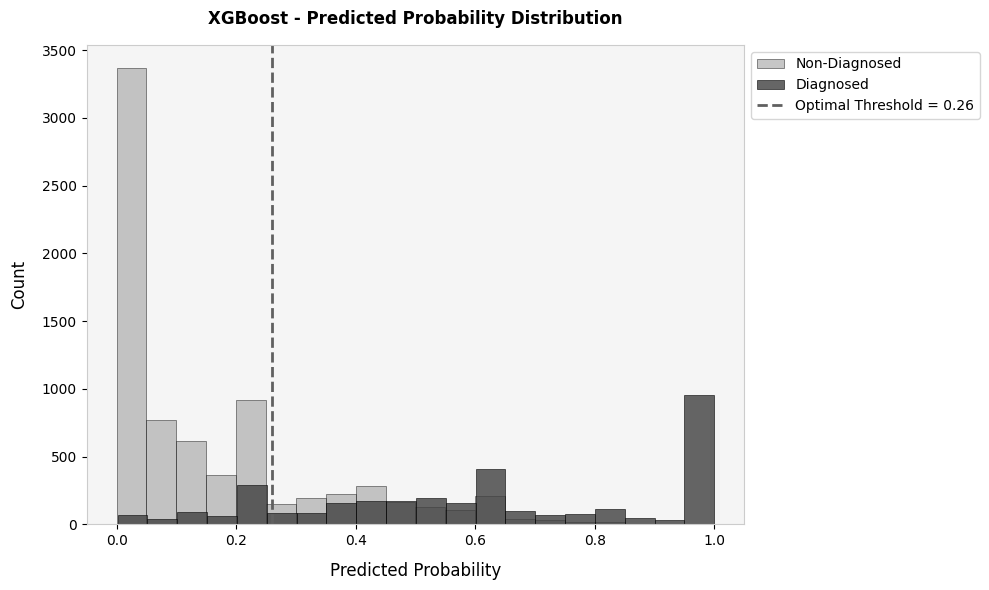


Logistic Regression - Feature Coefficients (Top 15 by absolute value):
--------------------------------------------------
  Stress Level (1-10)           : +5.579628 (↑ increases risk)
  Sleep Hours                   : -5.567246 (↓ decreases risk)
  Therapy Sessions (per month)  : +1.727037 (↑ increases risk)
  Caffeine Intake (mg/day)      : +1.517290 (↑ increases risk)
  Alcohol Consumption (drinks/week): +0.225831 (↑ increases risk)
  Medication                    : +0.210463 (↑ increases risk)
  Age                           : -0.190901 (↓ decreases risk)
  Recent Major Life Event       : +0.143319 (↑ increases risk)
  Heart Rate (bpm)              : +0.122618 (↑ increases risk)
  Occupation_Athlete            : -0.097862 (↓ decreases risk)
  Sweating Level (1-5)          : +0.092717 (↑ increases risk)
  Occupation_Student            : -0.089914 (↓ decreases risk)
  Diet Quality (1-10)           : -0.088284 (↓ decreases risk)
  Dizziness                     : +0.061192 (↑ increase

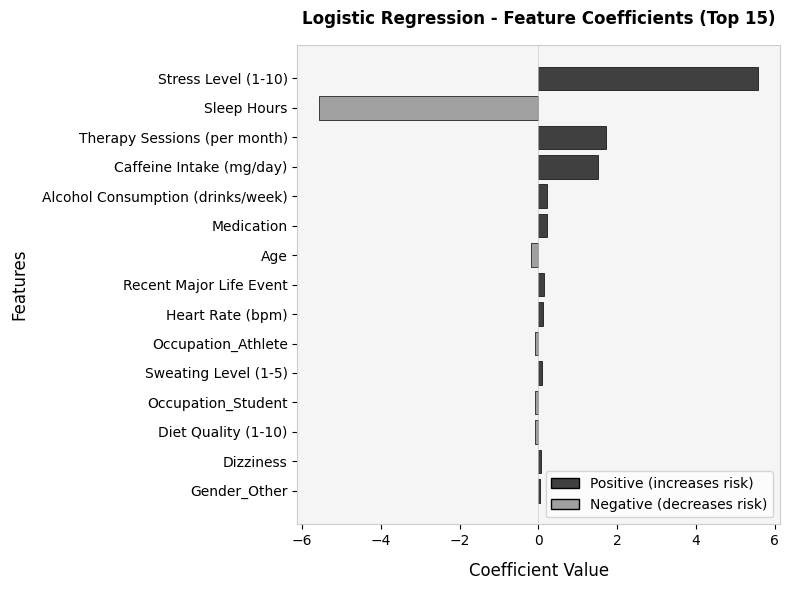


Random Forest - Feature Importances (Top 15):
--------------------------------------------------
  Stress Level (1-10)           : 0.476110
  Sleep Hours                   : 0.148280
  Caffeine Intake (mg/day)      : 0.078679
  Therapy Sessions (per month)  : 0.062334
  Physical Activity (hrs/week)  : 0.039263
  Heart Rate (bpm)              : 0.033535
  Diet Quality (1-10)           : 0.032816
  Age                           : 0.027579
  Breathing Rate (breaths/min)  : 0.025976
  Alcohol Consumption (drinks/week): 0.021759
  Sweating Level (1-5)          : 0.016825
  Recent Major Life Event       : 0.006445
  Medication                    : 0.005368
  Dizziness                     : 0.004420
  Gender_Other                  : 0.003558


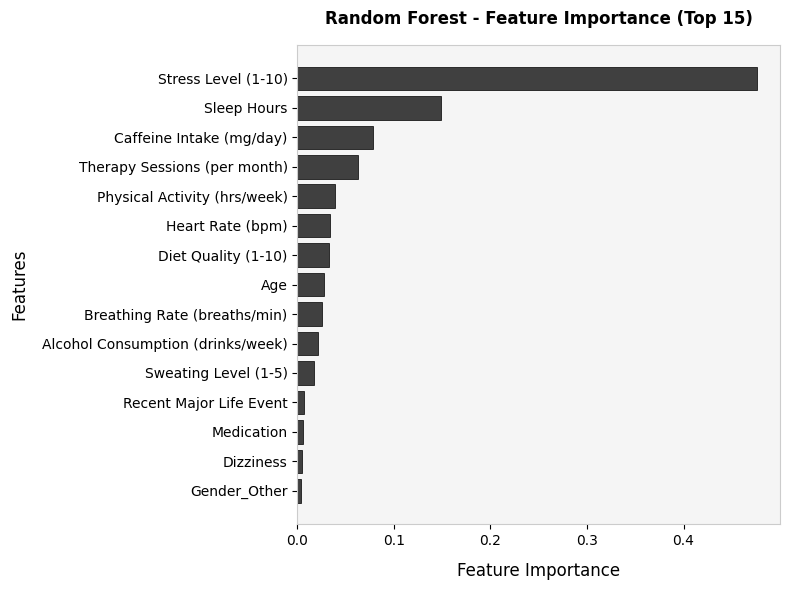


XGBoost - Feature Importances (Top 15):
--------------------------------------------------
  Stress Level (1-10)           : 0.439649
  Sleep Hours                   : 0.120012
  Diet Quality (1-10)           : 0.071663
  Caffeine Intake (mg/day)      : 0.060706
  Therapy Sessions (per month)  : 0.060516
  Physical Activity (hrs/week)  : 0.030854
  Occupation_Lawyer             : 0.028563
  Gender_Male                   : 0.019071
  Sweating Level (1-5)          : 0.018077
  Age                           : 0.017322
  Gender_Other                  : 0.016230
  Heart Rate (bpm)              : 0.015048
  Occupation_Athlete            : 0.014324
  Medication                    : 0.013791
  Alcohol Consumption (drinks/week): 0.013408


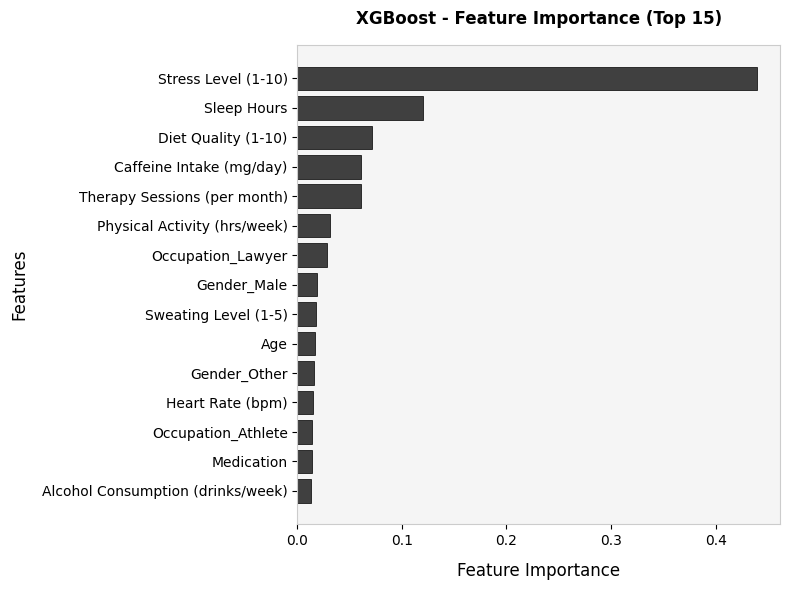


Logistic Regression (threshold=0.377)
  TN=6471  FP=1147  FN=761  TP=2621
  Sensitivity: 77.50%  Specificity: 84.94%
  F1: 0.7331  Accuracy: 82.65%  Precision: 69.56%
  ROC-AUC: 0.9049  Brier: 0.1114
              precision    recall  f1-score   support

           0     0.8948    0.8494    0.8715      7618
           1     0.6956    0.7750    0.7331      3382

    accuracy                         0.8265     11000
   macro avg     0.7952    0.8122    0.8023     11000
weighted avg     0.8335    0.8265    0.8290     11000


Random Forest (threshold=0.343)
  TN=6224  FP=1394  FN=643  TP=2739
  Sensitivity: 80.99%  Specificity: 81.70%
  F1: 0.7289  Accuracy: 81.48%  Precision: 66.27%
  ROC-AUC: 0.8997  Brier: 0.1131
              precision    recall  f1-score   support

           0     0.9064    0.8170    0.8594      7618
           1     0.6627    0.8099    0.7289      3382

    accuracy                         0.8148     11000
   macro avg     0.7845    0.8134    0.7942     11000
weigh

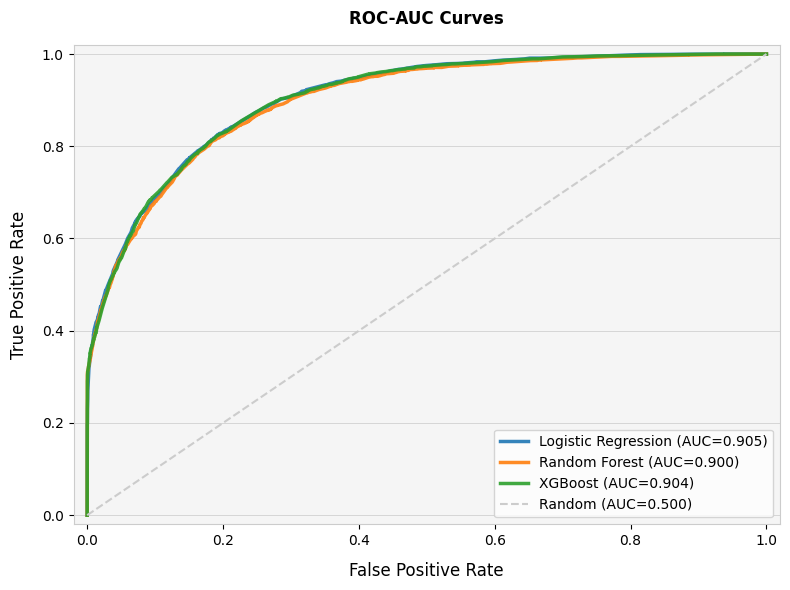

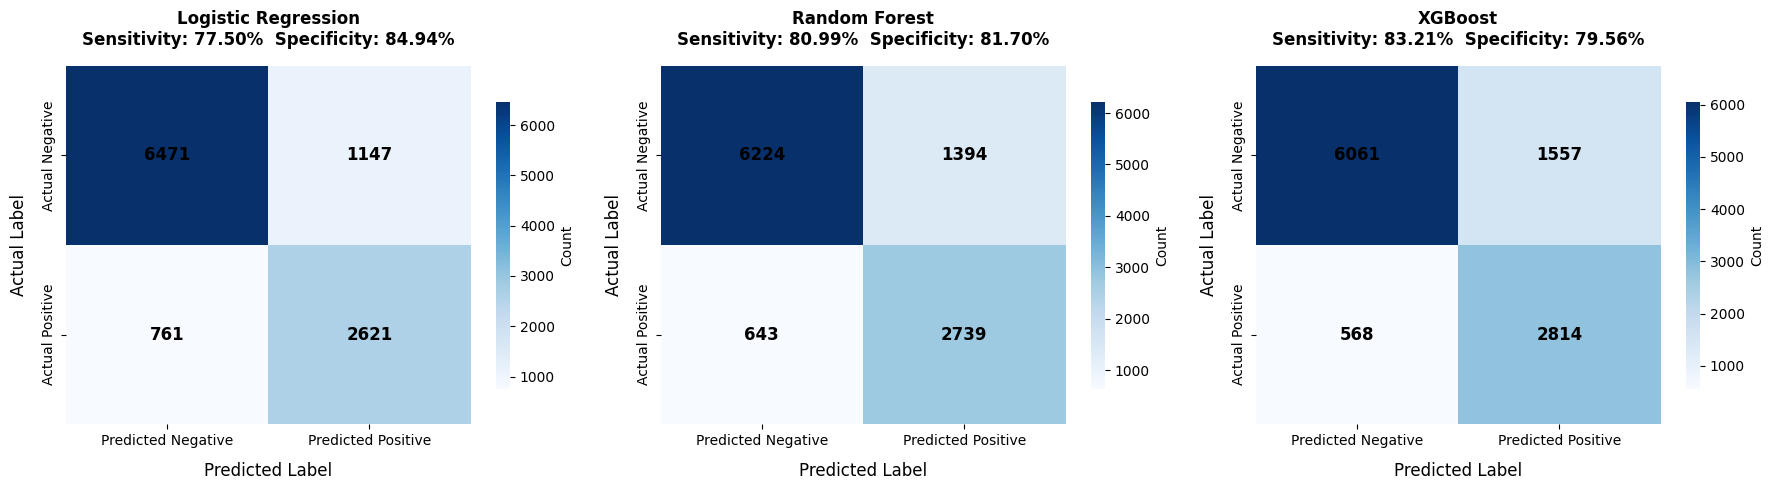

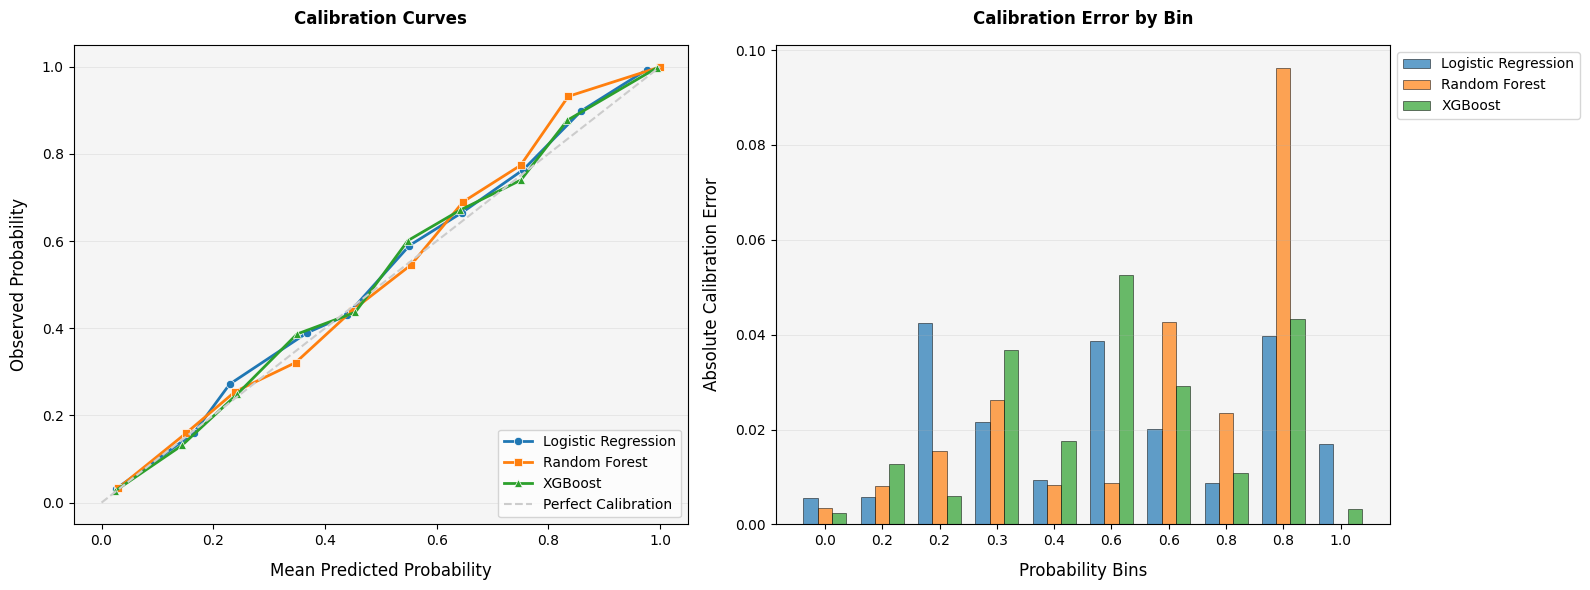

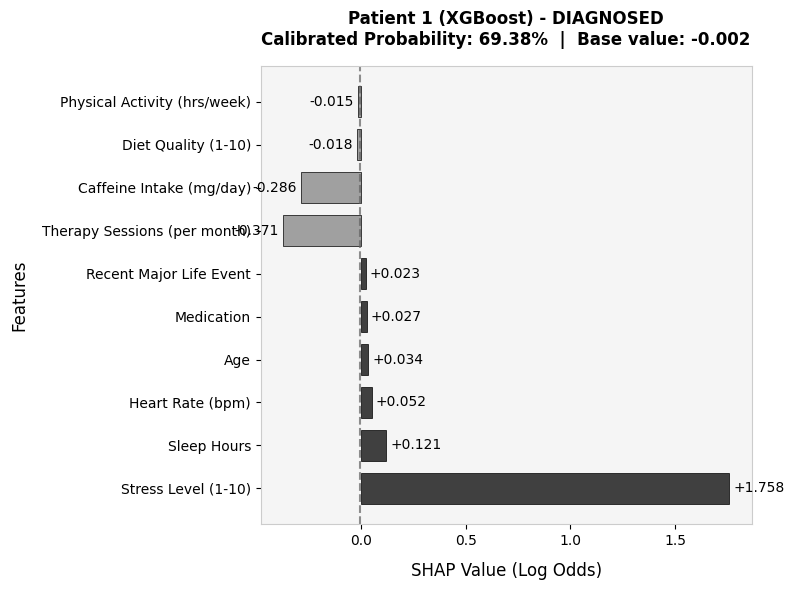

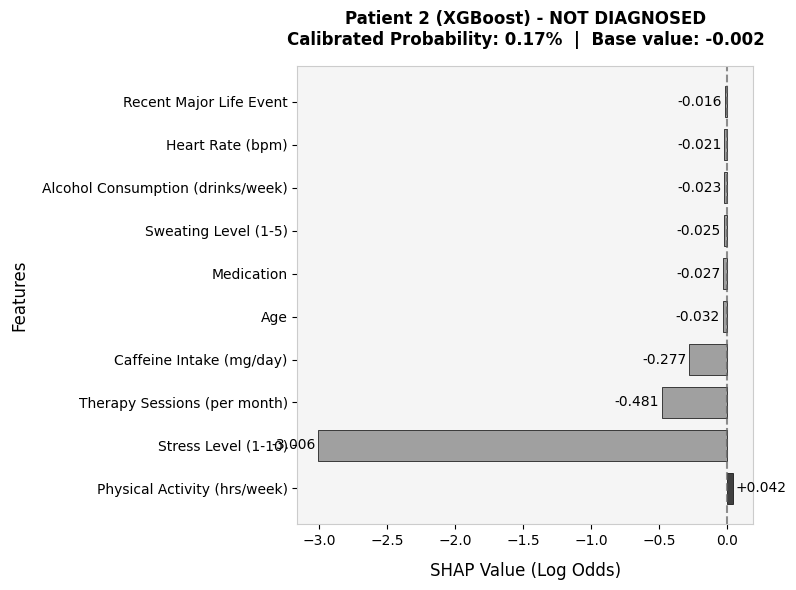

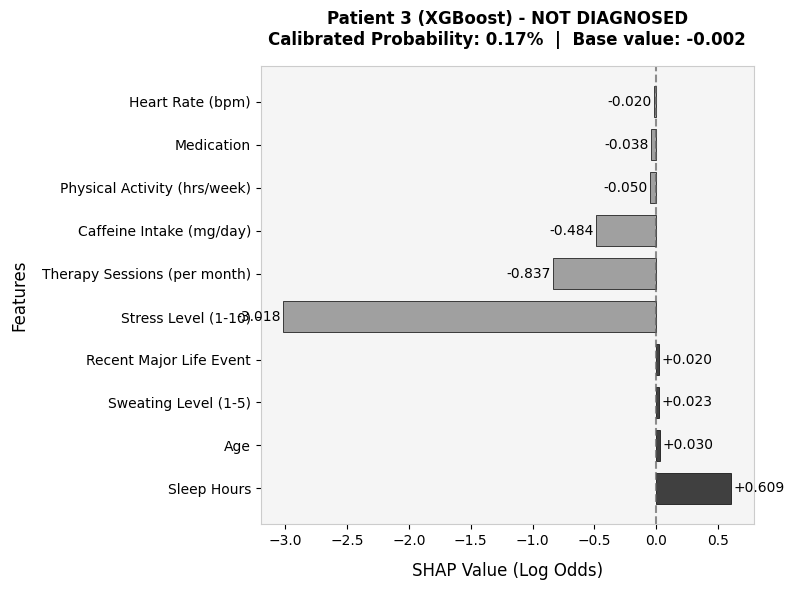

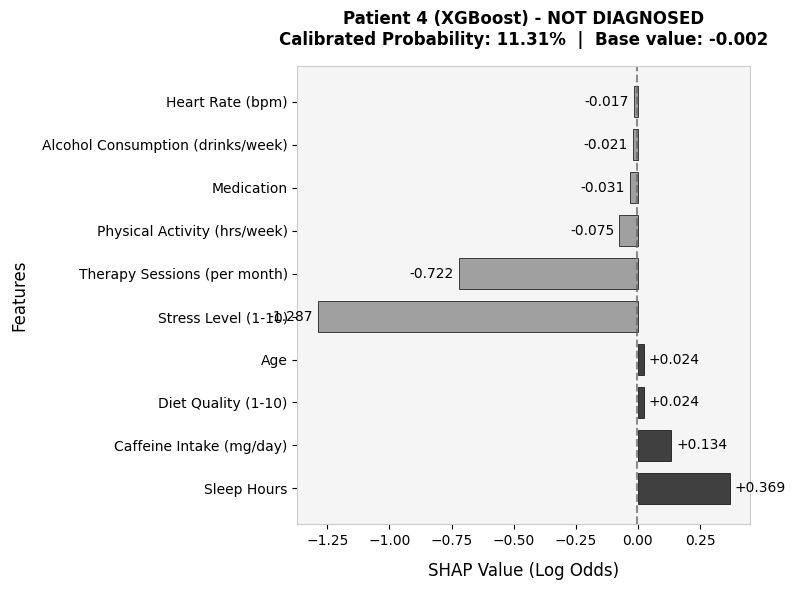


FIRST 10 PATIENTS — XGBoost
--------------------------------------------------------------------------------------------------------------
Patient: 1     | Diagnosis: Diagnosed     | Prob: 69.38 % | Risk: Moderate Risk
  ↑ Increasing: Stress Level (1-10) (+1.758), Sleep Hours (+0.121), Heart Rate (bpm) (+0.052), Age (+0.034), Medication (+0.027)
  ↓ Decreasing: Therapy Sessions (per month) (-0.371), Caffeine Intake (mg/day) (-0.286), Diet Quality (1-10) (-0.018), Physical Activity (hrs/week) (-0.015), Breathing Rate (breaths/min) (-0.011)
--------------------------------------------------------------------------------------------------------------
Patient: 2     | Diagnosis: Not Diagnosed | Prob: 0.17  % | Risk: Low Risk    
  ↑ Increasing: Physical Activity (hrs/week) (+0.042), Sleep Hours (+0.011), Occupation_Athlete (+0.002), Breathing Rate (breaths/min) (+0.002), Gender_Other (+0.001)
  ↓ Decreasing: Stress Level (1-10) (-3.006), Therapy Sessions (per month) (-0.481), Caffeine Int

['predictive_model_xgboost.pkl']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from matplotlib.patches import Patch
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve, brier_score_loss,
    precision_score, f1_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical


# ── Helpers ───────────────────────────────────────────────────────────────────

def style_plot(ax, title, xlabel, ylabel, legend=True, grid=True):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel(xlabel, fontsize=12, labelpad=10, color='black')
    ax.set_ylabel(ylabel, fontsize=12, labelpad=10, color='black')
    if grid:
        ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#666666')
        ax.grid(False, axis='x')
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=10, frameon=True, loc='upper left', bbox_to_anchor=(1, 1))
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    ax.set_facecolor('#f5f5f5')
    for spine in ax.spines.values():
        spine.set_color('#cccccc')
    return ax

def find_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return thresholds[np.argmax(tpr - fpr)]

def compute_sensitivity(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def evaluate_model(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred)
    auc   = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    print(f"\n{name} (threshold={threshold:.3f})")
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Sensitivity: {sensitivity*100:.2f}%  Specificity: {specificity*100:.2f}%")
    print(f"  F1: {f1:.4f}  Accuracy: {acc*100:.2f}%  Precision: {prec*100:.2f}%")
    print(f"  ROC-AUC: {auc:.4f}  Brier: {brier:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    return confusion_matrix(y_true, y_pred), {
        'sensitivity': sensitivity, 'specificity': specificity,
        'f1_score': f1, 'precision': prec, 'accuracy': acc, 'roc_auc': auc
    }

def categorize_risk(prob, low=0.3, high=0.7):
    if prob < low:  return "Low Risk"
    if prob < high: return "Moderate Risk"
    return "High Risk"

def get_top_shap_features(shap_vals_row, feat_names, n_top=5, positive=True):
    shap_vals_row = np.array(shap_vals_row, dtype=float).flatten()
    indices = np.argsort(shap_vals_row)[-n_top:][::-1] if positive else np.argsort(shap_vals_row)[:n_top]
    features = []
    for idx in indices:
        idx = int(idx)
        if positive and shap_vals_row[idx] > 0:
            features.append(f"{feat_names[idx]} (+{shap_vals_row[idx]:.3f})")
        elif not positive and shap_vals_row[idx] < 0:
            features.append(f"{feat_names[idx]} ({shap_vals_row[idx]:.3f})")
    while len(features) < n_top:
        features.append("")
    return features


# ── Data ──────────────────────────────────────────────────────────────────────

train_data = pd.read_csv("training_dataset.csv")
X_full = train_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_full = train_data["Diagnosed"]
X_full, y_full = shuffle(X_full, y_full, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

test_data = pd.read_csv("testing_dataset.csv")
X_test = test_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_test = test_data["Diagnosed"]

numeric_features     = X_train.select_dtypes(include=[float, int]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])


# ── Search Spaces ─────────────────────────────────────────────────────────────

logreg_space = {
    'classifier__C':        Real(0.01, 10, prior='log-uniform'),
    'classifier__l1_ratio': Categorical([0, 0.5, 1]),
    'classifier__solver':   Categorical(['saga']),
}

rf_space = {
    'classifier__n_estimators':      Integer(50, 200),
    'classifier__max_depth':         Integer(3, 15),
    'classifier__min_samples_split': Integer(2, 20),
    'classifier__min_samples_leaf':  Integer(1, 20),
    'classifier__max_features':      Categorical(['sqrt', 'log2']),
}

xgb_space = {
    'classifier__n_estimators':     Integer(100, 400),
    'classifier__max_depth':        Integer(3, 10),
    'classifier__learning_rate':    Real(0.05, 0.35, prior='log-uniform'),
    'classifier__subsample':        Real(0.6, 1.0),
    'classifier__colsample_bytree': Real(0.6, 1.0),
    'classifier__min_child_weight': Integer(1, 7),
    'classifier__reg_alpha':        Real(0, 2),
    'classifier__reg_lambda':       Real(0.5, 2.5),
}


# ── Pipelines & Tuning ────────────────────────────────────────────────────────

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1))
])

logreg_search = BayesSearchCV(logreg_pipeline, logreg_space, n_iter=20, cv=3,
                               scoring='roc_auc', n_jobs=-1, random_state=42)
logreg_search.fit(X_train, y_train)

rf_search = BayesSearchCV(rf_pipeline, rf_space, n_iter=20, cv=3,
                           scoring='roc_auc', n_jobs=-1, random_state=42)
rf_search.fit(X_train, y_train)

xgb_search = BayesSearchCV(xgb_pipeline, xgb_space, n_iter=20, cv=3,
                             scoring='roc_auc', n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)

best_logreg = logreg_search.best_estimator_
best_rf     = rf_search.best_estimator_
best_xgb    = xgb_search.best_estimator_


# ── Calibration ───────────────────────────────────────────────────────────────

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
best_xgb.named_steps['classifier'].set_params(scale_pos_weight=scale_pos_weight)

logreg_model = CalibratedClassifierCV(best_logreg, method="isotonic", cv=3)
rf_model     = CalibratedClassifierCV(best_rf,     method="isotonic", cv=3)
xgb_model    = CalibratedClassifierCV(best_xgb,    method="isotonic", cv=3)

logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)


# ── Thresholds & Best Model Selection (by validation sensitivity) ─────────────

logreg_val_prob = logreg_model.predict_proba(X_val)[:, 1]
rf_val_prob     = rf_model.predict_proba(X_val)[:, 1]
xgb_val_prob    = xgb_model.predict_proba(X_val)[:, 1]

logreg_threshold = find_best_threshold(y_val, logreg_val_prob)
rf_threshold     = find_best_threshold(y_val, rf_val_prob)
xgb_threshold    = find_best_threshold(y_val, xgb_val_prob)

val_sensitivity = {
    "Logistic Regression": compute_sensitivity(y_val, logreg_val_prob, logreg_threshold),
    "Random Forest":       compute_sensitivity(y_val, rf_val_prob,     rf_threshold),
    "XGBoost":             compute_sensitivity(y_val, xgb_val_prob,    xgb_threshold),
}

best_model_name = max(val_sensitivity, key=val_sensitivity.get)

model_map = {
    "Logistic Regression": (logreg_model, best_logreg, logreg_threshold),
    "Random Forest":       (rf_model,     best_rf,     rf_threshold),
    "XGBoost":             (xgb_model,    best_xgb,    xgb_threshold),
}
best_calibrated_model, best_raw_pipeline, best_threshold = model_map[best_model_name]


# ── Test Probabilities ────────────────────────────────────────────────────────

logreg_test_prob = logreg_model.predict_proba(X_test)[:, 1]
rf_test_prob     = rf_model.predict_proba(X_test)[:, 1]
xgb_test_prob    = xgb_model.predict_proba(X_test)[:, 1]

df_probs = pd.DataFrame({
    "Patient":                          range(1, 21),
    "Diagnosis (1=Anxiety, 0=No)":      y_test.iloc[:20].values,
    "Logistic Regression (%)":          np.round(logreg_test_prob[:20] * 100, 2),
    "Random Forest (%)":                np.round(rf_test_prob[:20]     * 100, 2),
    "XGBoost (%)":                      np.round(xgb_test_prob[:20]    * 100, 2),
})
print("\nPREDICTED PROBABILITIES — First 20 Patients")
print(df_probs.to_string(index=False))


# ── Probability Distribution Plots ───────────────────────────────────────────

def plot_probabilities_horizontal(y_true, y_prob, threshold, name):
    df = pd.DataFrame({"Probability": y_prob, "Diagnosis": y_true})
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, diagnosis in enumerate([0, 1]):
        data  = df[df["Diagnosis"] == diagnosis]
        label = "Non-Diagnosed" if diagnosis == 0 else "Diagnosed"
        ax.hist(data["Probability"], bins=20, alpha=0.6 if diagnosis == 0 else 0.8,
                color=['#a0a0a0', '#404040'][i], label=label, edgecolor='black', linewidth=0.5)
    ax.axvline(threshold, color='#606060', linestyle="--", linewidth=2,
               label=f"Optimal Threshold = {threshold:.2f}")
    style_plot(ax, f"{name} - Predicted Probability Distribution",
               "Predicted Probability", "Count", grid=False)
    plt.tight_layout()
    plt.show()

plot_probabilities_horizontal(y_test, logreg_test_prob, logreg_threshold, "Logistic Regression")
plot_probabilities_horizontal(y_test, rf_test_prob,     rf_threshold,     "Random Forest")
plot_probabilities_horizontal(y_test, xgb_test_prob,    xgb_threshold,    "XGBoost")


# ── Feature Importance ────────────────────────────────────────────────────────

def get_feature_names(X_train, numeric_features, categorical_features):
    temp = ColumnTransformer([
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ])
    temp.fit(X_train)
    return list(numeric_features) + list(
        temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
    )

def plot_feature_importance(pipeline_model, name, feat_names):
    classifier = pipeline_model.named_steps["classifier"]
    fig, ax = plt.subplots(figsize=(8, 6))
    
    if hasattr(classifier, "feature_importances_"):
        importances = classifier.feature_importances_
        indices = np.argsort(importances)[-15:]
        
        # Print feature importance
        print(f"\n{name} - Feature Importances (Top 15):")
        print("-" * 50)
        for idx in indices[::-1]:  # Print in descending order
            print(f"  {feat_names[idx]:<30}: {importances[idx]:.6f}")
        
        ax.barh(range(len(indices)), importances[indices], color='#404040',
                edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feat_names[i] for i in indices], fontsize=10)
        style_plot(ax, f"{name} - Feature Importance (Top 15)",
                   "Feature Importance", "Features", legend=False, grid=False)
                   
    elif hasattr(classifier, "coef_"):
        coefficients = classifier.coef_[0]
        indices = np.argsort(np.abs(coefficients))[-15:]
        
        # Print coefficients
        print(f"\n{name} - Feature Coefficients (Top 15 by absolute value):")
        print("-" * 50)
        for idx in indices[::-1]:  
            direction = "↑ increases risk" if coefficients[idx] > 0 else "↓ decreases risk"
            print(f"  {feat_names[idx]:<30}: {coefficients[idx]:+.6f} ({direction})")
        
        bar_colors = ['#404040' if c > 0 else '#a0a0a0' for c in coefficients[indices]]
        ax.barh(range(len(indices)), coefficients[indices], color=bar_colors,
                edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feat_names[i] for i in indices], fontsize=10)
        ax.legend(handles=[
            Patch(facecolor='#404040', edgecolor='black', label='Positive (increases risk)'),
            Patch(facecolor='#a0a0a0', edgecolor='black', label='Negative (decreases risk)')
        ], loc='lower right', fontsize=10, frameon=True)
        style_plot(ax, f"{name} - Feature Coefficients (Top 15)",
                   "Coefficient Value", "Features", legend=True, grid=False)
    
    ax.axvline(x=0, color='#cccccc', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# Re-fit on full training data for feature importance and SHAP
best_logreg.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

feat_names = get_feature_names(X_train, numeric_features, categorical_features)

plot_feature_importance(best_logreg, "Logistic Regression", feat_names)
plot_feature_importance(best_rf,     "Random Forest",       feat_names)
plot_feature_importance(best_xgb,    "XGBoost",             feat_names)


# ── Evaluation ────────────────────────────────────────────────────────────────

logreg_cm, logreg_metrics = evaluate_model(y_test, logreg_test_prob, logreg_threshold, "Logistic Regression")
rf_cm,     rf_metrics     = evaluate_model(y_test, rf_test_prob,     rf_threshold,     "Random Forest")
xgb_cm,    xgb_metrics    = evaluate_model(y_test, xgb_test_prob,    xgb_threshold,    "XGBoost")

comparison_df = pd.DataFrame({
    'Model':           ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Threshold':       [logreg_threshold, rf_threshold, xgb_threshold],
    'Sensitivity (%)': [m['sensitivity']*100 for m in [logreg_metrics, rf_metrics, xgb_metrics]],
    'Specificity (%)': [m['specificity']*100 for m in [logreg_metrics, rf_metrics, xgb_metrics]],
    'F1-Score':        [m['f1_score']         for m in [logreg_metrics, rf_metrics, xgb_metrics]],
    'Precision (%)':   [m['precision']*100    for m in [logreg_metrics, rf_metrics, xgb_metrics]],
    'Accuracy (%)':    [m['accuracy']*100     for m in [logreg_metrics, rf_metrics, xgb_metrics]],
    'ROC-AUC':         [m['roc_auc']          for m in [logreg_metrics, rf_metrics, xgb_metrics]],
}).round(2)

print("\nMODEL COMPARISON\n", comparison_df.to_string(index=False))


# ── ROC Curves ────────────────────────────────────────────────────────────────

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
fig, ax = plt.subplots(figsize=(8, 6))
for (name, prob), color in zip([("Logistic Regression", logreg_test_prob),
                                  ("Random Forest",       rf_test_prob),
                                  ("XGBoost",             xgb_test_prob)], colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})", alpha=0.9)
ax.plot([0, 1], [0, 1], color='#cccccc', linestyle='--', linewidth=1.5, label='Random (AUC=0.500)')
style_plot(ax, "ROC-AUC Curves", "False Positive Rate", "True Positive Rate")
ax.legend(fontsize=10, frameon=True, loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()


# ── Confusion Matrices ────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cm, ax, metrics, name in zip(
    [logreg_cm, rf_cm, xgb_cm], axes,
    [logreg_metrics, rf_metrics, xgb_metrics],
    ['Logistic Regression', 'Random Forest', 'XGBoost']
):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'],
                annot_kws={'size': 12, 'color': 'black', 'fontweight': 'bold'},
                cbar_kws={'label': 'Count', 'shrink': 0.8})
    ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10, color='black')
    ax.set_ylabel("Actual Label",    fontsize=12, labelpad=10, color='black')
    ax.set_title(f"{name}\nSensitivity: {metrics['sensitivity']:.2%}  "
                 f"Specificity: {metrics['specificity']:.2%}",
                 fontsize=12, fontweight='bold', pad=15, color='black')
    ax.tick_params(axis='both', labelsize=10, colors='black')
plt.tight_layout()
plt.show()


# ── Calibration Curves ────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
calibration_data = []
for prob, label, color, marker in zip(
    [logreg_test_prob, rf_test_prob, xgb_test_prob],
    ["Logistic Regression", "Random Forest", "XGBoost"],
    colors, ['o', 's', '^']
):
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    calibration_data.append((prob_pred, prob_true, label, color, marker))
    ax1.plot(prob_pred, prob_true, marker=marker, markersize=6, linewidth=2,
             color=color, label=label, markeredgecolor='white', markeredgewidth=0.5)

ax1.plot([0, 1], [0, 1], linestyle='--', color='#cccccc', linewidth=1.5, label='Perfect Calibration')
ax1.set_title('Calibration Curves', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Mean Predicted Probability', fontsize=12, labelpad=10)
ax1.set_ylabel('Observed Probability',       fontsize=12, labelpad=10)
ax1.grid(True, axis='y', alpha=0.3, linewidth=0.5)
ax1.legend(fontsize=10, frameon=True, loc='lower right')
ax1.set_facecolor('#f5f5f5')

bar_width = 0.25
index = np.arange(10)
for i, (prob_pred, prob_true, label, color, _) in enumerate(calibration_data):
    ax2.bar(index + (i - 1) * bar_width, np.abs(prob_true - prob_pred),
            bar_width, label=label, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Probability Bins',           fontsize=12, labelpad=10)
ax2.set_ylabel('Absolute Calibration Error', fontsize=12, labelpad=10)
ax2.set_title('Calibration Error by Bin',    fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(index)
ax2.set_xticklabels([f'{x:.1f}' for x in calibration_data[1][0]], fontsize=10)
ax2.legend(fontsize=10, frameon=True, loc='upper left', bbox_to_anchor=(1, 1))
ax2.grid(True, axis='y', alpha=0.3, linewidth=0.5)
ax2.set_facecolor('#f5f5f5')
plt.tight_layout()
plt.show()


# ── SHAP Analysis (best model) ────────────────────────────────────────────────

X_test_transformed_full = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
]).fit(X_train).transform(X_test)  # Use full X_test instead of subset

best_raw_classifier = best_raw_pipeline.named_steps["classifier"]

if hasattr(best_raw_classifier, "feature_importances_"):
    explainer   = shap.TreeExplainer(best_raw_classifier)
    shap_values = explainer.shap_values(X_test_transformed_full)
    if isinstance(shap_values, list):
        shap_values_class1 = np.array(shap_values[1])
        expected_value     = float(np.array(explainer.expected_value).flat[1])
    else:
        shap_values_class1 = np.array(shap_values)
        expected_value     = float(np.array(explainer.expected_value).flat[0])
elif hasattr(best_raw_classifier, "coef_"):
    explainer   = shap.LinearExplainer(best_raw_classifier, X_test_transformed_full)
    shap_values = explainer.shap_values(X_test_transformed_full)
    shap_values_class1 = np.array(shap_values)
    expected_value     = float(np.array(explainer.expected_value).flat[0])
else:
    raise ValueError(f"Unsupported classifier type: {type(best_raw_classifier)}")

if shap_values_class1.ndim == 3:
    shap_values_class1 = shap_values_class1[:, :, 1]
shap_values_class1 = shap_values_class1.reshape(len(X_test), len(feat_names))

best_calibrated_prob_full = best_calibrated_model.predict_proba(X_test)[:, 1]

# Still create a subset for waterfall plots (first 4 patients)
SHAP_SAMPLE_SIZE = min(4, len(X_test))  # Changed to 4 for waterfall plots
X_test_subset    = X_test.iloc[:SHAP_SAMPLE_SIZE]
y_test_subset    = y_test.iloc[:SHAP_SAMPLE_SIZE]
shap_values_subset = shap_values_class1[:SHAP_SAMPLE_SIZE]
best_calibrated_prob_subset = best_calibrated_prob_full[:SHAP_SAMPLE_SIZE]

def plot_grayscale_waterfall(shap_vals_row, expected_val, feat_names,
                             calibrated_prob, true_diagnosis, max_display=10, patient_num=None):
    feature_impacts = [(name, float(val)) for name, val in zip(feat_names, shap_vals_row)]
    feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)
    top = feature_impacts[:max_display]
    pos = sorted([(n, v) for n, v in top if v > 0], key=lambda x: x[1], reverse=True)
    neg = sorted([(n, v) for n, v in top if v < 0], key=lambda x: x[1])
    sorted_features = pos + neg

    labels = [n for n, _ in sorted_features]
    values = [v for _, v in sorted_features]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(len(values)), values,
            color=['#404040' if v > 0 else '#a0a0a0' for v in values],
            edgecolor='black', linewidth=0.5, height=0.7)
    for i, v in enumerate(values):
        ax.text(v + 0.02 if v > 0 else v - 0.02, i,
                f'+{v:.3f}' if v > 0 else f'{v:.3f}',
                va='center', ha='left' if v > 0 else 'right', fontsize=10, color='black')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=13)
    ax.axvline(x=expected_val, color='#606060', linestyle='--', linewidth=1.5, alpha=0.7)
    diagnosis_text = 'DIAGNOSED' if true_diagnosis == 1 else 'NOT DIAGNOSED'
    ax.set_title(
        f"Patient {patient_num} ({best_model_name}) - {diagnosis_text}\n"
        f"Calibrated Probability: {calibrated_prob:.2%}  |  Base value: {expected_val:.3f}",
        fontsize=12, fontweight='bold', pad=15, color='black'
    )
    ax.set_xlabel('SHAP Value (Log Odds)', fontsize=12, labelpad=10, color='black')
    ax.set_ylabel('Features', fontsize=12, labelpad=10, color='black')
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=10, colors='black')
    ax.set_facecolor('#f5f5f5')
    for spine in ax.spines.values():
        spine.set_color('#cccccc')
    plt.tight_layout()
    plt.show()

# Plot waterfalls for first 3 patients
for i in range(len(X_test_subset)):
    plot_grayscale_waterfall(
        np.array(shap_values_subset[i], dtype=float).flatten(),
        expected_value, feat_names,
        best_calibrated_prob_subset[i],
        y_test_subset.iloc[i],
        max_display=10, patient_num=i + 1
    )

# ── Results Table (FULL dataset) ───────────────────────────────────────────────

# Generate top features for ALL patients (using full dataset)
top_increase = [get_top_shap_features(shap_values_class1[i], feat_names, positive=True)
                for i in range(len(best_calibrated_prob_full))]
top_decrease = [get_top_shap_features(shap_values_class1[i], feat_names, positive=False)
                for i in range(len(best_calibrated_prob_full))]

results_table = pd.DataFrame({
    "Patient":            range(1, len(best_calibrated_prob_full) + 1),
    "Diagnosis":          ["Diagnosed" if v == 1 else "Not Diagnosed" for v in y_test.values],
    "Predicted Prob (%)": np.round(best_calibrated_prob_full * 100, 2),
    "Risk Category":      [categorize_risk(p) for p in best_calibrated_prob_full],
    "Top 5 Increasing":   [", ".join(f for f in feat if f) for feat in top_increase],
    "Top 5 Decreasing":   [", ".join(f for f in feat if f) for feat in top_decrease],
})

results_table.to_csv("predictions_with_explanation.csv", index=False)

def print_patient_report(rows, title):
    print(f"\n{title}")
    print("-" * 110)
    for _, row in rows.iterrows():
        print(f"Patient: {row['Patient']:<5} | Diagnosis: {row['Diagnosis']:<13} | "
              f"Prob: {row['Predicted Prob (%)']:<6}% | Risk: {row['Risk Category']:<12}")
        print(f"  ↑ Increasing: {row['Top 5 Increasing']}")
        print(f"  ↓ Decreasing: {row['Top 5 Decreasing']}")
        print("-" * 110)

print_patient_report(results_table.head(10), f"FIRST 10 PATIENTS — {best_model_name}")
print_patient_report(results_table.tail(10), f"LAST 10 PATIENTS  — {best_model_name}")


# ── Risk Distribution (full test set) ────────────────────────────────────────

best_test_prob_full = best_calibrated_model.predict_proba(X_test)[:, 1]
risk_summary = (
    pd.Series([categorize_risk(p) for p in best_test_prob_full], name='Risk Category')
    .value_counts()
    .reindex(["Low Risk", "Moderate Risk", "High Risk"])
    .dropna()
    .to_frame('Count')
)
risk_summary['Percentage'] = (risk_summary['Count'] / len(best_test_prob_full) * 100).round(2)
print(f"\nRISK DISTRIBUTION — {best_model_name} (n={len(best_test_prob_full)})")
print(risk_summary.to_string())


# ── Save Best Model ───────────────────────────────────────────────────────────

model_filename = f"predictive_model_{best_model_name.lower().replace(' ', '_')}.pkl"
joblib.dump(best_calibrated_model, model_filename, compress=3)